# 📌 Importação de bibliotecas

In [1]:
import numpy as np
import pandas as pd

In [2]:
from typing import Union

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

In [5]:
from scipy.stats import f_oneway
from scipy.stats import levene
from scipy import stats
import pingouin as pg

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_validate, KFold
from sklearn.model_selection import StratifiedKFold
from imblearn.pipeline import Pipeline as imbpipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import NearMiss
from yellowbrick.model_selection import FeatureImportances

from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_squared_log_error, mean_absolute_percentage_error
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import PrecisionRecallDisplay
from sklearn.metrics import average_precision_score
from sklearn.metrics import classification_report
from yellowbrick.classifier import ClassificationReport
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve, auc, precision_recall_curve
)

In [7]:
import copy

In [8]:
import warnings

## Importação de pacotes locais

In [9]:
import src.local_tools as lt
import src.telecomx_analysis as ta
import src.telecomx_machine_learning as tml

## Configurações do ambiente

In [10]:
pd.set_option('display.max_columns', None)

In [11]:
warnings.simplefilter(action='ignore', category=FutureWarning)

## Constantes

In [12]:
NUM_SEMENTE_ALEATORIA = 42
TAMANHO_TESTE = 0.3
MAXIMO_ITERACAO = 1000

In [13]:
LIST_SCORING = ['accuracy','recall', 'precision', 'f1']

# 📌 Extração de dados

In [14]:
df_dados = pd.read_csv('./dados/dados_tratados.csv')

In [15]:
df_dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customerID                    7043 non-null   object 
 1   Churn                         7043 non-null   int64  
 2   customer_gender               7043 non-null   object 
 3   customer_SeniorCitizen        7043 non-null   int64  
 4   customer_Partner              7043 non-null   int64  
 5   customer_Dependents           7043 non-null   int64  
 6   customer_tenure               7043 non-null   int64  
 7   phone_PhoneService            7043 non-null   int64  
 8   phone_MultipleLines           7043 non-null   int64  
 9   internet_InternetService      7043 non-null   int64  
 10  internet_OnlineSecurity       7043 non-null   int64  
 11  internet_OnlineBackup         7043 non-null   int64  
 12  internet_DeviceProtection     7043 non-null   int64  
 13  int

In [16]:
df_dados.nunique()

customerID                      7043
Churn                              2
customer_gender                    2
customer_SeniorCitizen             2
customer_Partner                   2
customer_Dependents                2
customer_tenure                   72
phone_PhoneService                 2
phone_MultipleLines                2
internet_InternetService           2
internet_OnlineSecurity            2
internet_OnlineBackup              2
internet_DeviceProtection          2
internet_TechSupport               2
internet_StreamingTV               2
internet_StreamingMovies           2
account_Contract                   3
account_PaperlessBilling           2
account_PaymentMethod              4
account_Charges_Monthly         1585
account_Charges_Total           6534
internet_Service_Description       3
customer_tenure_bins               6
account_Charges_Monthly_bins       6
account_Charges_Total_bins        13
account_Contract_Monthly           2
additional_InternetService         7
o

Verificar dados duplicados

In [17]:
df_dados.duplicated().sum()

0

# 📌 Tratamento de dados

In [18]:
df_ohe = tml.df_final_modelo_v1(df_dados)

# 📌 Seleção e validação dos modelos de treinamento

## Tabela de verificação de padronização dos dados

| Modelo                 | Precisa padronizar? | Tipo de padronização (se necessário)   |
| ---------------------- | ------------------- | -------------------------------------- |
| DecisionTreeClassifier | ❌ Não               | —                                      |
| LogisticRegression     | ✅ Sim               | `StandardScaler` (média 0, desvio 1)   |
| RandomForest           | ❌ Não               | —                                      |
| XGBoost                | ⚠️ Opcional         | Pode ajudar (StandardScaler ou MinMax) |
| LightGBM               | ⚠️ Opcional         | Pode ajudar (StandardScaler ou MinMax) |
| CatBoost               | ❌ Não               | —                                      |


## Conceitos sobre as métricas de um modelo

Aqui está o quadro comparativo para churn (evasão de clientes), considerando que a classe positiva é “cliente vai sair”:

| **Métrica**                | **O que mede**                                                                     | **Quando valor é alto**                                        | **Risco quando valor é baixo**                                   | **Custo de erro associado**                                                |
| -------------------------- | ---------------------------------------------------------------------------------- | -------------------------------------------------------------- | ---------------------------------------------------------------- | -------------------------------------------------------------------------- |
| **Precisão (Precision)**   | Entre todos que o modelo previu como “vai sair”, qual porcentagem realmente saiu   | Você gasta retenção apenas em quem de fato sairia              | Gastar recursos em retenção de clientes que iam ficar (FP alto)  | **Custo financeiro** com campanhas desnecessárias (descontos, bônus, etc.) |
| **Recall (Sensibilidade)** | Entre todos que realmente saíram, qual porcentagem o modelo previu como “vai sair” | Você identifica a maior parte dos clientes que iam sair        | Deixar escapar clientes que saem (FN alto)                       | **Perda de receita** e potencial perda de market share                     |
| **F1-Score**               | Média harmônica de precisão e recall                                               | Equilíbrio entre acertar quem vai sair e evitar falsos alarmes | Ou alto custo de retenção inútil ou perda de clientes — ou ambos | **Equilíbrio financeiro e estratégico** — custo total menor                |
| **FP (Falso Positivo)**    | Previu saída, mas o cliente ficaria                                                | —                                                              | Gastar para reter quem não ia sair                               | Desperdício de budget de retenção                                          |
| **FN (Falso Negativo)**    | Previu permanência, mas o cliente saiu                                             | —                                                              | Não agir para reter quem realmente sairia                        | Perda direta de receita + possível impacto na reputação                    |
    

📌 Resumo visual da prioridade

    Se retenção for muito cara → priorizar alta precisão.

    Se perder clientes for muito prejudicial → priorizar alto recall.

    Se quer balancear ambos → otimizar F1-Score.

## Split base de dados em train e test

In [19]:
X = df_ohe.drop(columns=['Churn'])

In [20]:
y = df_ohe.Churn

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = NUM_SEMENTE_ALEATORIA, test_size=TAMANHO_TESTE, stratify=y)

## Treinamento do Modelo - XGBoost

In [22]:
from xgboost import XGBClassifier

In [23]:
model_xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=NUM_SEMENTE_ALEATORIA
)

In [24]:
X_train.columns

Index(['customer_SeniorCitizen', 'customer_Partner', 'customer_Dependents',
       'phone_MultipleLines', 'account_PaperlessBilling',
       'account_Contract_Monthly', 'charges_total_bin__inf_96_62_',
       'charges_total_bin__1182_80_3273_68_',
       'charges_total_bin__198_05_347_90_',
       'charges_total_bin__3273_68_4838_38_',
       'charges_total_bin__347_90_547_73_',
       'charges_total_bin__4838_38_5644_60_',
       'charges_total_bin__547_73_1182_80_',
       'charges_total_bin__5644_60_6623_50_',
       'charges_total_bin__6623_50_inf_', 'charges_total_bin__96_62_198_05_',
       'internet_Service_Description_DSL',
       'internet_Service_Description_Fiber_optic',
       'additional_InternetService_0', 'additional_InternetService_1',
       'additional_InternetService_2', 'additional_InternetService_3',
       'additional_InternetService_4', 'additional_InternetService_5',
       'additional_InternetService_6', 'account_PaymentMethod_automatic',
       'account_Paymen

In [25]:
# Treinando o modelo com as colunas limpas
model_xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, gpu_id=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, predictor=None, random_state=42, ...)

In [26]:
# 8️⃣ Fazer previsões
y_pred_xgb = model_xgb.predict(X_test)
y_pred_proba_xgb = model_xgb.predict(X_test)

<Figure size 1000x600 with 0 Axes>

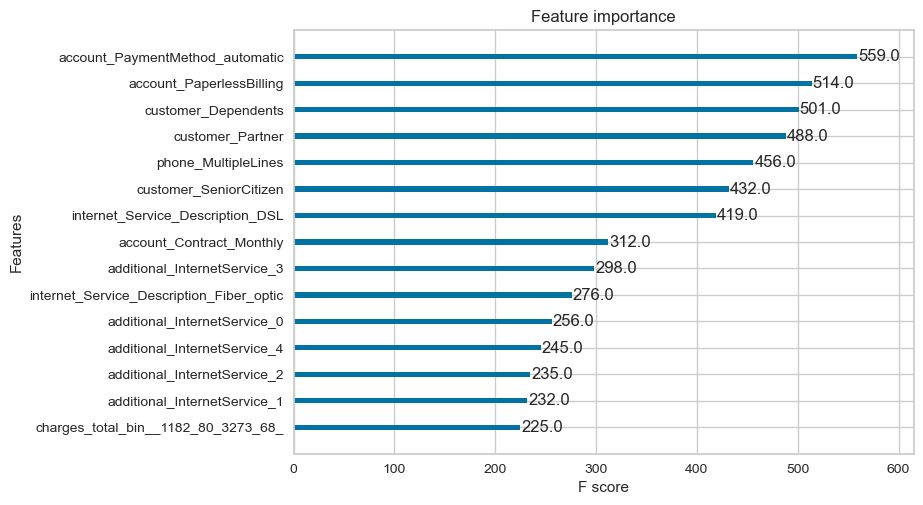

In [27]:
# 🔟 Importância das variáveis
from xgboost import plot_importance

plt.figure(figsize=(10,6))
plot_importance(model_xgb, max_num_features=15)
plt.show()

### Relatório de métricas

In [28]:
tml.avaliar_modelo(y_test, y_pred_xgb, y_pred_proba_xgb, False)

Métricas:
Acurácia: 0.7851
Precisão: 0.6197
Recall: 0.4938
F1-Score: 0.5496
ROC AUC: 0.6921

Relatório de classificação:

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1552
           1       0.62      0.49      0.55       561

    accuracy                           0.79      2113
   macro avg       0.72      0.69      0.70      2113
weighted avg       0.77      0.79      0.78      2113


Matrix de confusão:

[[1382  170]
 [ 284  277]]


In [29]:
tml.df_classifier_metrics(y_test, y_pred_xgb, y_pred_proba_xgb, ['XGBClassifier'])

,accuracy,precision,recall,f1,roc_auc,support,True Negative,False Positive,False Negative,True Positive
XGBClassifier,0.78514,0.619687,0.493761,0.549603,0.692113,2113,1382,170,284,277


In [31]:
list_df = []
colunas_binarias = lt.identify_columns_binary_values(X_test)
for c in colunas_binarias:
    list_df.append(tml.df_specific_confusion_matrix(X_test, y_test, y_pred_xgb, c))
df_independent = pd.concat(list_df, axis=0)

E:\Local_Drive\Cursos Livres\ONE\06-Estatística e Machine Learning G8 - ONE\08-Challenge Telecom X - análise de evasão de clientes - Parte 2\TelecomX_parte2_BR\scripts\telecomx_machine_learning.py:253: RuntimeWarning: invalid value encountered in scalar divide
  f1_score = (2 * precision * recall) / (precision + recall)
E:\Local_Drive\Cursos Livres\ONE\06-Estatística e Machine Learning G8 - ONE\08-Challenge Telecom X - análise de evasão de clientes - Parte 2\TelecomX_parte2_BR\scripts\telecomx_machine_learning.py:251: RuntimeWarning: invalid value encountered in scalar divide
  precision = tp / (tp + fp)


In [32]:
df_independent.reset_index()

,index,filter_value,support,accuracy,negative predictive value,precision,recall,f1-score,TN,FP,FN,TP
0,customer_SeniorCitizen,1,349,0.733524,0.768116,0.683099,0.668966,0.675958,159,45,48,97
1,customer_Partner,1,1032,0.823643,0.856828,0.580645,0.356436,0.441718,778,52,130,72
2,customer_Dependents,1,616,0.849026,0.878947,0.478261,0.241758,0.321168,501,24,69,22
3,phone_MultipleLines,1,883,0.778029,0.825954,0.640351,0.561538,0.598361,541,82,114,146
4,account_PaperlessBilling,1,1213,0.752679,0.806996,0.635417,0.603960,0.619289,669,140,160,244
5,account_Contract_Monthly,1,1182,0.673435,0.706122,0.619687,0.561866,0.589362,519,170,216,277
6,charges_total_bin__inf_96_62_,1,242,0.673554,0.669355,0.677966,0.661157,0.669456,83,38,41,80
7,charges_total_bin__1182_80_3273_68_,1,564,0.778369,0.831169,0.539216,0.413534,0.468085,384,47,78,55
8,charges_total_bin__198_05_347_90_,1,144,0.763889,0.814433,0.659574,0.632653,0.645833,79,16,18,31
9,charges_total_bin__3273_68_4838_38_,1,214,0.850467,0.884422,0.400000,0.206897,0.272727,176,9,23,6


### Otimizando os hiperparâmetros com o GridSearchCV

In [33]:
param_grid = {
    'n_estimators': [50, 100, 200],       # Número de árvores
    'max_depth': [3, 5, 7],               # Profundidade máxima das árvores
    'learning_rate': [0.01, 0.1, 0.2],    # Taxa de aprendizado
    'subsample': [0.8, 1.0],              # Amostragem das instâncias
    'colsample_bytree': [0.8, 1.0]        # Amostragem das features
}

In [34]:
model_xgb = XGBClassifier(
    eval_metric="logloss",
    random_state=NUM_SEMENTE_ALEATORIA
)

In [35]:
model_grid_xgb = GridSearchCV(
    estimator=model_xgb,
    param_grid=param_grid,
    scoring='recall',
    cv=5,
    n_jobs=-1,
    verbose=1
)

In [36]:
model_grid_xgb.fit(X_train, y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     gamma=None, gpu_id=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     n_estimators=100, n_jobs=None,
                                     num_parallel_tree=None, predictor=None,
                                     random_state=42, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 1.0],
                         'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 5, 7], 'n_estimators': [50, 100, 200],
                         'subsample': [0.8, 1.0]},
             scoring='recall', verbose=1)

In [37]:
model_grid_xgb.best_params_

{'colsample_bytree': 1.0,
 'learning_rate': 0.01,
 'max_depth': 3,
 'n_estimators': 50,
 'subsample': 1.0}

In [38]:
y_pred_grid_xgb = model_grid_xgb.predict(X_test)

In [39]:
y_pred_proba_grid_xgb = model_grid_xgb.predict_proba(X_test)

In [40]:
tml.df_classifier_metrics(y_test, y_pred_grid_xgb, y_pred_proba_grid_xgb, ['XGBClassifier - Grid'])

,accuracy,precision,recall,f1,roc_auc,support,True Negative,False Positive,False Negative,True Positive
XGBClassifier - Grid,0.762423,0.547049,0.611408,0.577441,0.806317,2113,1268,284,218,343


### Consolidação das métricas

In [43]:
df_metricas = []

df_metricas.append(tml.df_classifier_metrics(y_test, y_pred_xgb, y_pred_proba_xgb, ['XGBClassifier']))

df_metricas.append(tml.df_classifier_metrics(y_test, y_pred_grid_xgb, y_pred_proba_grid_xgb, ['XGBClassifier - Grid']))

df_metricas = pd.concat(df_metricas, axis=0)
df_metricas

,accuracy,precision,recall,f1,roc_auc,support,True Negative,False Positive,False Negative,True Positive
XGBClassifier,0.785140,0.619687,0.493761,0.549603,0.692113,2113,1382,170,284,277
XGBClassifier - Grid,0.762423,0.547049,0.611408,0.577441,0.806317,2113,1268,284,218,343


In [38]:
df_metricas.to_clipboard()